This notebook takes the work to extract foliage, and saves the resulting geojson

The initial stages are identical to the visibility analysis; they should be grouped and done together to save time on finding datasets/opening and closing fles etc.

In [63]:
# for dev work

import sys
import importlib
import matplotlib.pyplot as plt

import folium
from folium import plugins
import json

import geopandas as gpd
import numpy as np

# Add src to path (do this once at the top)
sys.path.insert(0, '../../src')

# Initial import
import park_vga

# After editing:
importlib.reload(park_vga.defining_grids)
importlib.reload(park_vga.lidar)
importlib.reload(park_vga)

<module 'park_vga' from '/Users/maeve/Documents/park-vga/notebooks/modularising_the_approach/../../src/park_vga/__init__.py'>

In [5]:
boundaries_file = "../../example_datasets/Leeds_pp_or_g_cmb.geojson"
primary_name = "Woodhouse Moor"

buffer_distance = 20 # metres

lidar_dtm = "/Volumes/Extreme SSD/DTM"
lidar_dsm = "/Volumes/Extreme SSD/FZ_DSM"

In [6]:
park_gdf = park_vga.load_data(boundaries_file, primary_name, buffer_distance)
park_files = park_vga.park_geometry_to_file_path(park_gdf, lidar_dtm, lidar_dsm)

if park_files == ([], []):
    print("No files found for park 1")
else:
    print("Files found for park 1")

Files found for park 1


In [7]:
hex_grid = park_vga.create_hexagon_grid(park_gdf, spacing=10, return_mode='both')

Created 2349 pointy-top hexagons (10m vertical spacing)


In [8]:
lidar_data = park_vga.load_lidar_rasters_for_park(
    park_gdf, 
    park_files[0],  # dtm_paths
    park_files[1]   # dsm_paths
)

Loading 2 DSM and 2 DTM files
DSM valid pixels: 12500000 of 12500000 (100.0%)
DTM valid pixels: 12500000 of 12500000 (100.0%)
Output shape: (370, 301), Height range: -0.1m to 22.3m


In [ ]:
def extract_foliage_by_hexgrid_v1(height_raster, transform, hex_polygons, 
                               min_height=1.0, crs='EPSG:27700'):
    """
    Extract foliage statistics from height raster, aggregated to hexagon grid.
    Outputs point-based GeoJSON with foliage metrics per hex.
    
    Parameters:
    -----------
    height_raster : ndarray
        Height above ground raster (DSM - DTM, NaN for no data)
    transform : rasterio.Affine
        Georeferencing transform for the raster
    hex_polygons : list of tuples
        Output from create_hexagon_polygons_from_bounds()
        [(Point(centroid), Polygon(hex_boundary)), ...]
    min_height : float
        Minimum vegetation height threshold (m)
    crs : str
        Coordinate reference system
    
    Returns:
    --------
    GeoDataFrame
        Points with columns: geometry, max_height, mean_height, 
        std_height, count_pixels, percent_cover, percent_cover_height_bands
    """
    from rasterio.transform import rowcol
    from rasterio.mask import mask
    from rasterio.io import MemoryFile
    
    foliage_data = []
    
    print(f"Extracting foliage data from {len(hex_polygons)} hexagons...")
    
    for hex_idx, (centroid, hex_poly) in enumerate(hex_polygons):
        
        # Create temporary raster memory file to clip to hex boundary
        temp_meta = {
            'driver': 'GTiff',
            'height': height_raster.shape[0],
            'width': height_raster.shape[1],
            'count': 1,
            'dtype': height_raster.dtype,
            'crs': crs,
            'transform': transform,
            'nodata': np.nan
        }
        
        try:
            with MemoryFile() as memfile:
                with memfile.open(**temp_meta) as dataset:
                    dataset.write(height_raster, 1)
                    
                    # Mask raster to hexagon boundary
                    clipped, clipped_transform = mask(
                        dataset, 
                        [hex_poly.__geo_interface__], 
                        crop=False,
                        nodata=np.nan
                    )
                    clipped = clipped[0]
            
            # Extract valid (non-NaN) values
            valid_mask = ~np.isnan(clipped)
            valid_heights = clipped[valid_mask]
            
            # Count pixels above minimum height threshold
            above_threshold = valid_heights[valid_heights >= min_height]
            
            # Calculate statistics
            if len(valid_heights) > 0:
                max_height = float(np.nanmax(valid_heights))
                mean_height = float(np.nanmean(valid_heights))
                std_height = float(np.nanstd(valid_heights))
                count_pixels = int(np.sum(valid_mask))
                percent_cover = float(np.sum(valid_mask) / valid_mask.size * 100)
                percent_above_threshold = float(len(above_threshold) / count_pixels * 100) if count_pixels > 0 else 0.0
            else:
                max_height = np.nan
                mean_height = np.nan
                std_height = np.nan
                count_pixels = 0
                percent_cover = 0.0
                percent_above_threshold = 0.0
            
            # Height band percentages (might use?)
            height_bands = {
                'percent_1_2m': float(np.sum((valid_heights >= 1.0) & (valid_heights < 2.0)) / count_pixels * 100) if count_pixels > 0 else 0.0,
                'percent_2_5m': float(np.sum((valid_heights >= 2.0) & (valid_heights < 5.0)) / count_pixels * 100) if count_pixels > 0 else 0.0,
                'percent_5_10m': float(np.sum((valid_heights >= 5.0) & (valid_heights < 10.0)) / count_pixels * 100) if count_pixels > 0 else 0.0,
                'percent_10m_plus': float(np.sum(valid_heights >= 10.0) / count_pixels * 100) if count_pixels > 0 else 0.0,
            }
            
            foliage_data.append({
                'geometry': centroid,
                'max_height': max_height,
                'mean_height': mean_height,
                'std_height': std_height,
                'count_pixels': count_pixels,
                'percent_cover': percent_cover,
                'percent_above_1m': percent_above_threshold,
                **height_bands
            })
        
        except Exception as e:
            # If clipping fails (hex outside raster bounds), record NaNs
            foliage_data.append({
                'geometry': centroid,
                'max_height': np.nan,
                'mean_height': np.nan,
                'std_height': np.nan,
                'count_pixels': 0,
                'percent_cover': 0.0,
                'percent_above_1m': 0.0,
                'percent_1_2m': 0.0,
                'percent_2_5m': 0.0,
                'percent_5_10m': 0.0,
                'percent_10m_plus': 0.0,
            })
        
        if (hex_idx + 1) % max(1, len(hex_polygons) // 10) == 0:
            print(f"  Processed {hex_idx + 1} / {len(hex_polygons)} hexagons")
    
    # Convert to GeoDataFrame
    foliage_gdf = gpd.GeoDataFrame(foliage_data, crs=crs)
    
    return foliage_gdf

In [39]:
def extract_foliage_by_hexgrid(height_raster, transform, hex_polygons, 
                               min_height=2, crs='EPSG:27700'):
    """
    Extract foliage statistics from height raster, aggregated to hexagon grid.
    Outputs point-based GeoJSON with foliage metrics per hex.
    
    Parameters:
    -----------
    height_raster : ndarray
        Height above ground raster (DSM - DTM, NaN for no data)
    transform : rasterio.Affine
        Georeferencing transform for the raster
    hex_polygons : list of tuples
        Output from create_hexagon_polygons_from_bounds()
        [(Point(centroid), Polygon(hex_boundary)), ...]
    min_height : float
        Minimum vegetation height threshold (m)
    crs : str
        Coordinate reference system
    
    Returns:
    --------
    GeoDataFrame
        Points with columns: geometry, max_height, mean_height, 
        std_height, count_pixels, percent_cover, percent_cover_height_bands
    """
    from rasterio.transform import rowcol
    from rasterio.mask import mask
    from rasterio.io import MemoryFile
    
    foliage_data = []
    
    print(f"Extracting foliage data from {len(hex_polygons)} hexagons...")
    
    for hex_idx, (centroid, hex_poly) in enumerate(hex_polygons):
        
        # Create temporary raster memory file to clip to hex boundary
        temp_meta = {
            'driver': 'GTiff',
            'height': height_raster.shape[0],
            'width': height_raster.shape[1],
            'count': 1,
            'dtype': height_raster.dtype,
            'crs': crs,
            'transform': transform,
            'nodata': np.nan
        }
        
        try:
            with MemoryFile() as memfile:
                with memfile.open(**temp_meta) as dataset:
                    dataset.write(height_raster, 1)
                    
                    # Mask raster to hexagon boundary
                    clipped, clipped_transform = mask(
                        dataset, 
                        [hex_poly.__geo_interface__], 
                        crop=False,
                        nodata=np.nan
                    )
                    clipped = clipped[0]
            
            # Extract valid (non-NaN) values
            valid_mask = ~np.isnan(clipped)
            valid_heights = clipped[valid_mask]
            
            # Count pixels above minimum height threshold
            above_threshold = valid_heights[valid_heights >= min_height]
            
            # Calculate statistics
            if len(valid_heights) > 0:
                max_height = float(np.nanmax(valid_heights))
                mean_height = float(np.nanmean(valid_heights))
                std_height = float(np.nanstd(valid_heights))
                count_pixels = int(np.sum(valid_mask))
                percent_cover = float(np.sum(valid_mask) / valid_mask.size * 100)
                percent_above_threshold = float(len(above_threshold) / count_pixels * 100) if count_pixels > 0 else 0.0
            else:
                max_height = np.nan
                mean_height = np.nan
                std_height = np.nan
                count_pixels = 0
                percent_cover = 0.0
                percent_above_threshold = 0.0
            
            # Height band percentages (might use?)
            height_bands = {
                'low_level_<0.5': float(np.sum((valid_heights >= 0.15) & (valid_heights < 0.5)) / count_pixels * 100) if count_pixels > 0 else 0.0,
                'mid_level_0.5-2': float(np.sum((valid_heights >= 0.5) & (valid_heights < 2.0)) / count_pixels * 100) if count_pixels > 0 else 0.0,
                'tall_2+': float(np.sum(valid_heights >= 2.0) / count_pixels * 100) if count_pixels > 0 else 0.0,
            }
            
            foliage_data.append({
                'geometry': centroid,
                'max_height': max_height,
                'mean_height': mean_height,
                'std_height': std_height,
                'count_pixels': count_pixels,
                'percent_cover': percent_cover,
                f'percent_above_{min_height}m': percent_above_threshold,
                **height_bands
            })
        
        except Exception as e:
            # If clipping fails (hex outside raster bounds), record NaNs
            foliage_data.append({
                'geometry': centroid,
                'max_height': np.nan,
                'mean_height': np.nan,
                'std_height': np.nan,
                'count_pixels': 0,
                'percent_cover': 0.0,
                'percent_above_1m': 0.0,
                'low_level_<0.5': 0.0,
                'mid_level_0.5-2': 0.0,
                'tall_2+': 0.0,
            })
        
        if (hex_idx + 1) % max(1, len(hex_polygons) // 10) == 0:
            print(f"  Processed {hex_idx + 1} / {len(hex_polygons)} hexagons")
    
    # Convert to GeoDataFrame
    foliage_gdf = gpd.GeoDataFrame(foliage_data, crs=crs)
    
    return foliage_gdf

In [40]:
hex_polygons = list(zip(
    hex_grid['centroids'].geometry,
    hex_grid['polygons'].geometry
))


In [43]:
foliage_stats = extract_foliage_by_hexgrid(
    height_raster=lidar_data['height_above_ground'],
    transform=lidar_data['transform'],
    hex_polygons=hex_polygons,
    min_height=2.0,
    crs='EPSG:27700'
)

Extracting foliage data from 2349 hexagons...
  Processed 234 / 2349 hexagons
  Processed 468 / 2349 hexagons
  Processed 702 / 2349 hexagons
  Processed 936 / 2349 hexagons
  Processed 1170 / 2349 hexagons
  Processed 1404 / 2349 hexagons
  Processed 1638 / 2349 hexagons
  Processed 1872 / 2349 hexagons
  Processed 2106 / 2349 hexagons
  Processed 2340 / 2349 hexagons


above took 3 seconds

In [44]:
foliage_stats

,geometry,max_height,mean_height,std_height,count_pixels,percent_cover,percent_above_2.0m,low_level_<0.5,mid_level_0.5-2,tall_2+
0,POINT (429079.393 434705.602),12.562996,9.827196,2.150681,5,0.004490,100.000000,0.000000,0.000000,100.000000
1,POINT (429090.94 434705.602),2.943001,0.411518,0.790443,13,0.011673,7.692308,7.692308,23.076923,7.692308
2,POINT (429102.487 434705.602),3.242249,0.361499,1.018502,9,0.008081,11.111111,0.000000,0.000000,11.111111
3,POINT (429050.525 434715.602),0.000504,0.000252,0.000252,2,0.001796,0.000000,0.000000,0.000000,0.000000
4,POINT (429062.072 434715.602),0.001251,0.000020,0.000520,14,0.012571,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...
2344,POINT (428935.055 435435.602),10.637001,1.446936,2.823497,27,0.024244,18.518519,18.518519,14.814815,18.518519
2345,POINT (428946.602 435435.602),9.044746,1.585444,2.625390,18,0.016162,22.222222,22.222222,27.777778,22.222222
2346,POINT (428958.149 435435.602),5.483757,5.483757,0.000000,1,0.000898,100.000000,0.000000,0.000000,100.000000
2347,POINT (428969.696 435435.602),4.735756,3.587501,1.087728,8,0.007183,87.500000,0.000000,12.500000,87.500000


<Axes: >

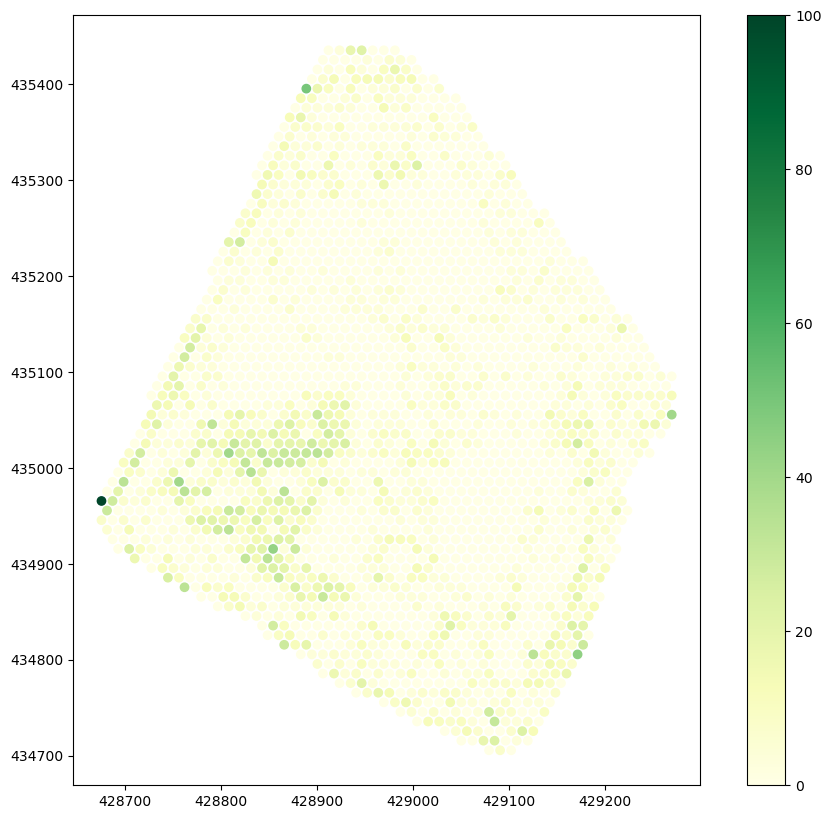

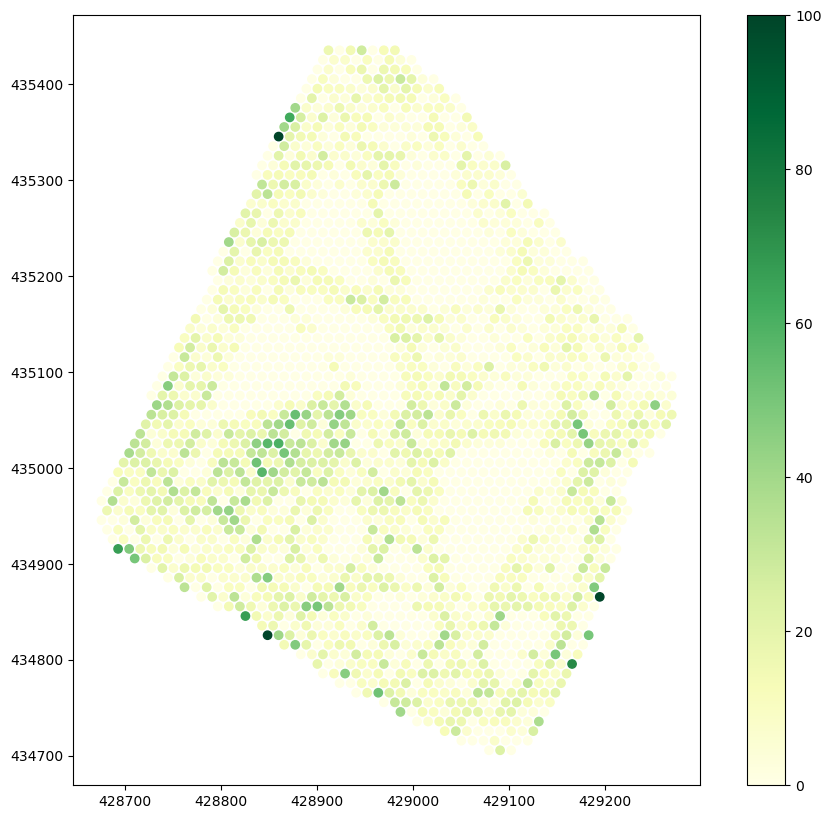

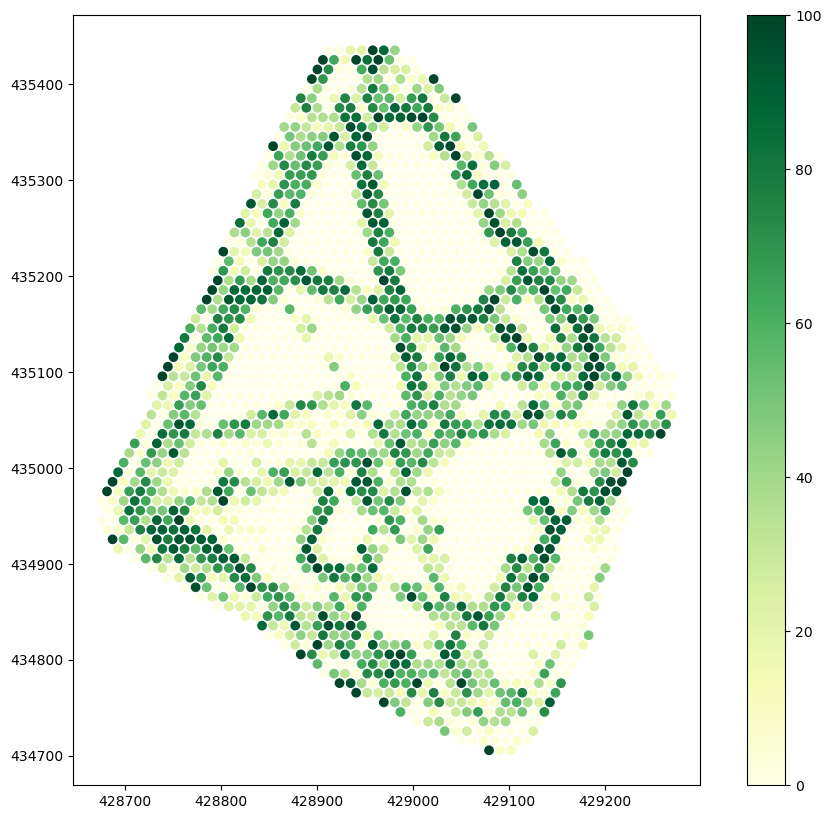

In [47]:
foliage_stats.plot(column='low_level_<0.5', cmap='YlGn', legend=True, figsize=(12, 10))

foliage_stats.plot(column='mid_level_0.5-2', cmap='YlGn', legend=True, figsize=(12, 10))

foliage_stats.plot(column='tall_2+', cmap='YlGn', legend=True, figsize=(12, 10))

In [48]:
# Rename current geometry column to 'centroids' and set polygon geometry
foliage_stats['centroids'] = foliage_stats.geometry
foliage_stats = foliage_stats.set_geometry(hex_grid["polygons"].geometry)

<Axes: >

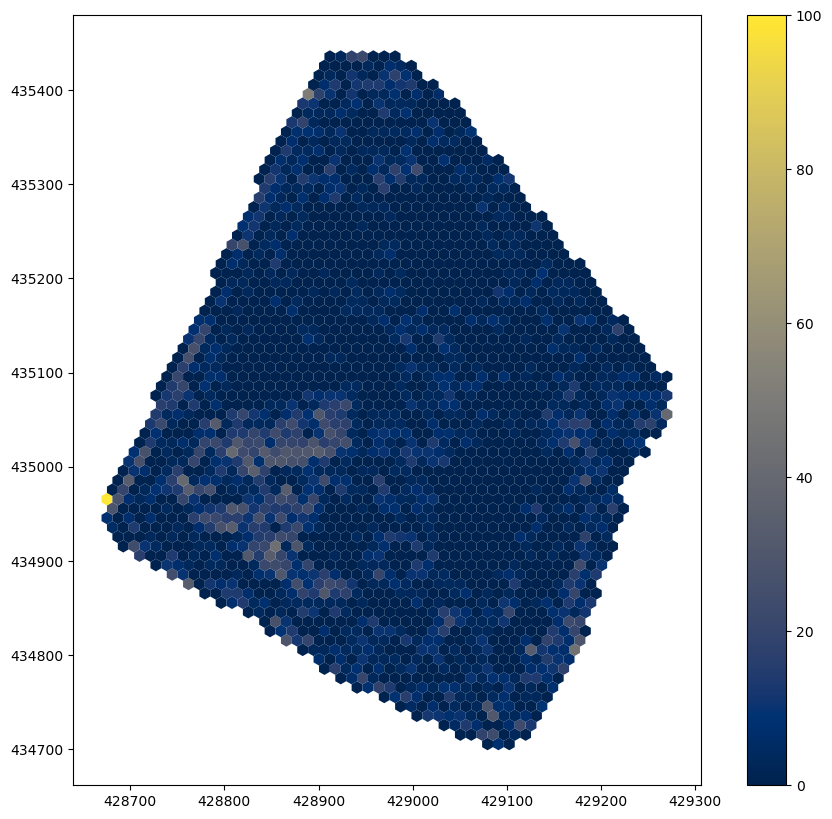

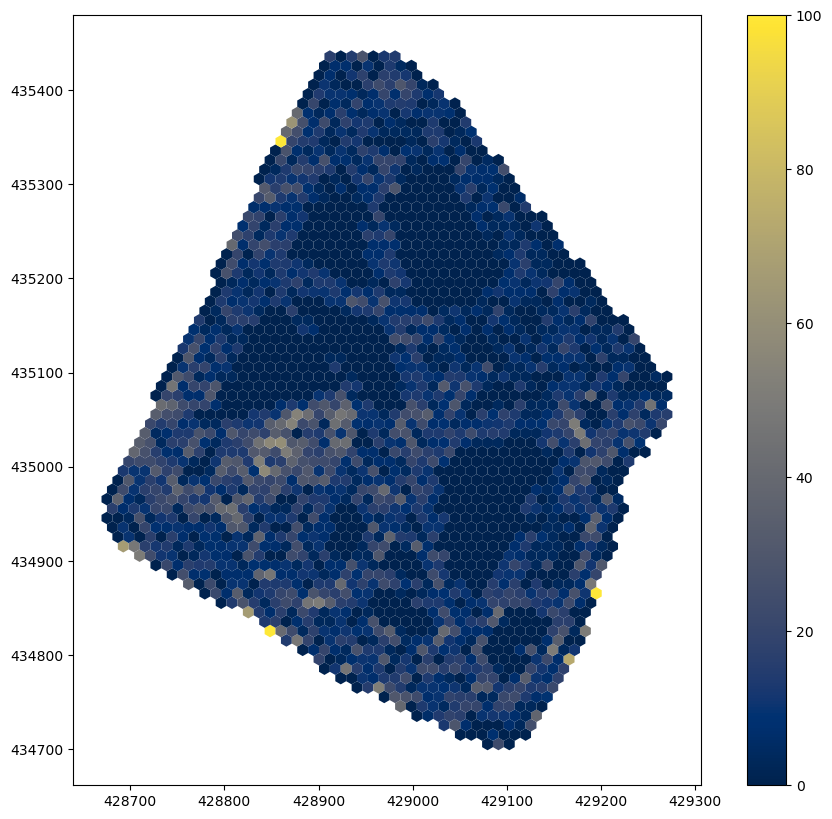

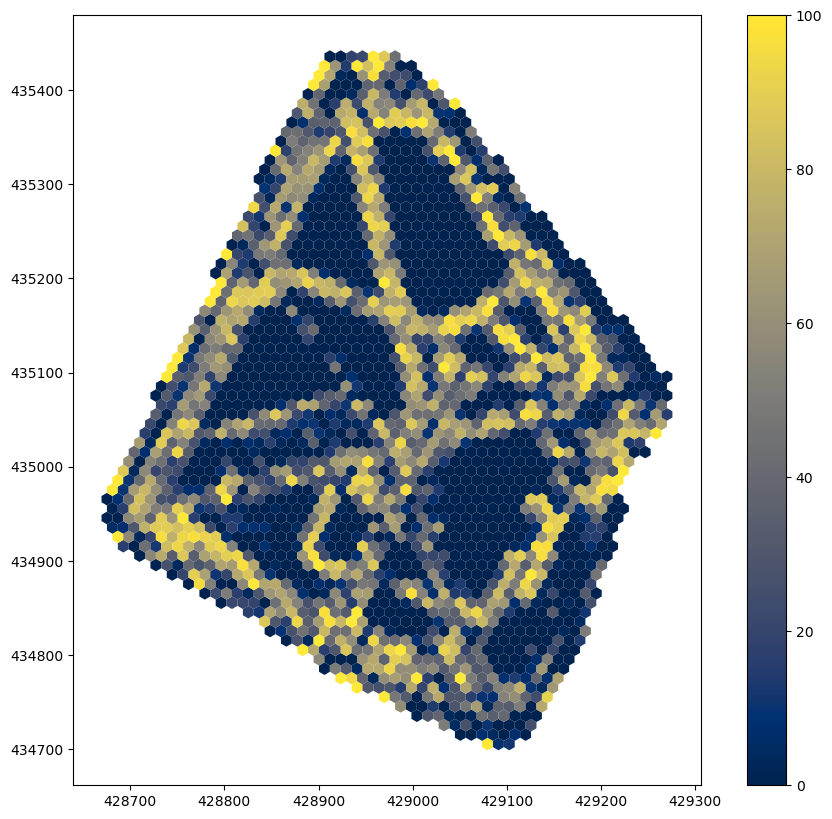

In [53]:
foliage_stats.plot(column='low_level_<0.5', cmap='cividis', legend=True, figsize=(12, 10),)

foliage_stats.plot(column='mid_level_0.5-2', cmap='cividis', legend=True, figsize=(12, 10))

foliage_stats.plot(column='tall_2+', cmap='cividis', legend=True, figsize=(12, 10))

![alt text](image-2.png)

In [ ]:
# foliage_output = foliage_stats.drop(columns=['centroids']).to_crs('EPSG:4326')
# foliage_output.to_file('../../outputs/foliage_results_v2_binned.geojson', driver='GeoJSON')

In [57]:
import folium
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import json

# Reproject to WGS84
foliage_wgs84 = foliage_stats.drop(columns=['centroids']).to_crs('EPSG:4326')

# Create map centered on the park
center_lat = foliage_wgs84.geometry.centroid.y.mean()
center_lon = foliage_wgs84.geometry.centroid.x.mean()

m = folium.Map(
    location=[center_lat, center_lon],
    zoom_start=14,
    tiles='CartoDB positron'
)

# Define the three columns and their properties
layers_config = [
    {'column': 'low_level_<0.5', 'name': 'Low Level (<0.5m)', 'show': True},
    {'column': 'mid_level_0.5-2', 'name': 'Mid Level (0.5-2m)', 'show': True},
    {'column': 'tall_2+', 'name': 'Tall (2m+)', 'show': True},
]

# Create color mapping function with vmin=10
cmap = cm.get_cmap('cividis')

def get_color(value, vmin=10, vmax=100):
    if value < vmin:
        return None  # No color for values below vmin
    norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
    return mcolors.to_hex(cmap(norm(value)))

# Create a layer for each column
for layer_config in layers_config:
    column = layer_config['column']
    layer_name = layer_config['name']
    
    # Convert to GeoJSON
    geojson_data = json.loads(foliage_wgs84.to_json())
    
    # Create a FeatureGroup for this layer
    fg = folium.FeatureGroup(name=layer_name, show=layer_config['show'])
    
    # Add each feature with appropriate styling
    for feature in geojson_data['features']:
        props = feature['properties']
        value = props.get(column)
        
        if value is not None and value >= 10:
            color = get_color(value)
            folium.GeoJson(
                data=feature,
                style_function=lambda x, col=color: {
                    'fillColor': col,
                    'color': 'black',
                    'weight': 0.5,
                    'fillOpacity': 0.7
                }
            ).add_to(fg)
    
    fg.add_to(m)

# Add layer control to toggle layers on/off
folium.LayerControl().add_to(m)

m.show_in_browser()

/var/folders/3s/z86xkbn12m94tfxyzcgrwf080000gn/T/ipykernel_19072/705249839.py:11: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  center_lat = foliage_wgs84.geometry.centroid.y.mean()
/var/folders/3s/z86xkbn12m94tfxyzcgrwf080000gn/T/ipykernel_19072/705249839.py:12: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  center_lon = foliage_wgs84.geometry.centroid.x.mean()
/var/folders/3s/z86xkbn12m94tfxyzcgrwf080000gn/T/ipykernel_19072/705249839.py:28: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('cividis')
765:773: execution

Your map should have been opened in your browser automatically.
Press ctrl+c to return.


Now doing this for a second park, using functions as imported from the package.

In [59]:
park_2 = "LEEDS_24c20c1a69e8;LEEDS_26c1e2aa11e8"
park2_gdf = park_vga.load_data(boundaries_file, park_2, buffer_distance, type="id")

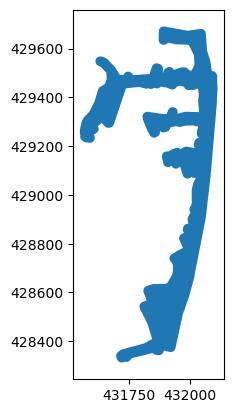

In [69]:
park_vga.check_plot(park2_gdf)

In [70]:
park2_files= park_vga.park_geometry_to_file_path(park2_gdf, lidar_dtm, lidar_dsm)

In [71]:
lidar_data = park_vga.load_lidar_rasters_for_park(
    park2_gdf, 
    park2_files[0],  # dtm_paths
    park2_files[1]   # dsm_paths
)

Loading 1 DSM and 1 DTM files
DSM valid pixels: 6250000 of 6250000 (100.0%)
DTM valid pixels: 6250000 of 6250000 (100.0%)
Output shape: (690, 283), Height range: -0.1m to 16.0m


In [72]:
hex_grid = park_vga.create_hexagon_grid(park2_gdf, spacing=10, return_mode='both')

Created 2207 pointy-top hexagons (10m vertical spacing)


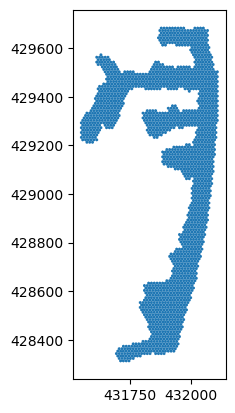

In [73]:
park_vga.check_plot(hex_grid['polygons'])

In [74]:
hex_polygons = list(zip(
    hex_grid['centroids'].geometry,
    hex_grid['polygons'].geometry
))



In [86]:
foliage_stats = park_vga.extract_foliage_by_hexgrid(
    height_raster=lidar_data['height_above_ground'],
    transform=lidar_data['transform'],
    hex_polygons=hex_polygons,
    min_height=2.0,
    crs='EPSG:27700'
)

Extracting foliage data from 2207 hexagons...
  Processed 220 / 2207 hexagons
  Processed 440 / 2207 hexagons
  Processed 660 / 2207 hexagons
  Processed 880 / 2207 hexagons
  Processed 1100 / 2207 hexagons
  Processed 1320 / 2207 hexagons
  Processed 1540 / 2207 hexagons
  Processed 1760 / 2207 hexagons
  Processed 1980 / 2207 hexagons
  Processed 2200 / 2207 hexagons


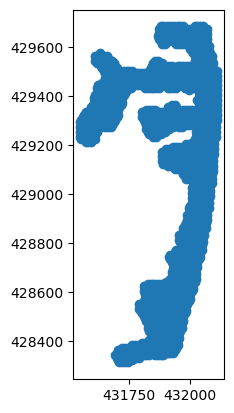

In [87]:
park_vga.check_plot(foliage_stats)

In [88]:
# Rename current geometry column to 'centroids' and set polygon geometry
foliage_stats['centroids'] = foliage_stats.geometry
foliage_stats = foliage_stats.set_geometry(hex_grid["polygons"].geometry)

In [102]:
## Clipping option 1: directly

# # Reload park boundary without buffer
# park_original = park_vga.load_data(boundaries_file, park_2, 5, type="id")

# # Clip to original boundary
# foliage_clipped = foliage_stats.clip(park_original.geometry.iloc[0])

# Keep hexagons that intersect (touch or overlap) the park boundary
park_original = park_vga.load_data(boundaries_file, park_2, 0, type="id")
park_boundary = park_original.geometry.iloc[0]

foliage_clipped = foliage_stats[foliage_stats.geometry.intersects(park_boundary)]

print(f"Before filtering: {len(foliage_stats)}")
print(f"After filtering: {len(foliage_clipped)}")

Before filtering: 2207
After filtering: 1167


In [103]:
foliage_clipped.head()

,geometry,max_height,mean_height,std_height,count_pixels,percent_cover,percent_above_2.0m,low_level_<0.5,mid_level_0.5-2,tall_2+,centroids
12,"POLYGON ((431728.049 428336.294, 431722.275 42...",9.501747,2.926232,3.186952,28,0.014339,46.428571,7.142857,21.428571,46.428571,POINT (431722.275 428332.961)
13,"POLYGON ((431739.596 428336.294, 431733.822 42...",6.367752,1.152389,1.877992,29,0.014851,24.137931,6.896552,13.793103,24.137931,POINT (431733.822 428332.961)
14,"POLYGON ((431751.143 428336.294, 431745.369 42...",3.002747,0.661651,0.938697,30,0.015363,16.666667,6.666667,20.000000,16.666667,POINT (431745.369 428332.961)
21,"POLYGON ((431722.275 428346.294, 431716.502 42...",6.238503,1.854758,1.246225,30,0.015363,33.333333,6.666667,56.666667,33.333333,POINT (431716.502 428342.961)
22,"POLYGON ((431733.822 428346.294, 431728.049 42...",5.380997,1.212466,1.518181,30,0.015363,20.000000,10.000000,30.000000,20.000000,POINT (431728.049 428342.961)


<Axes: >

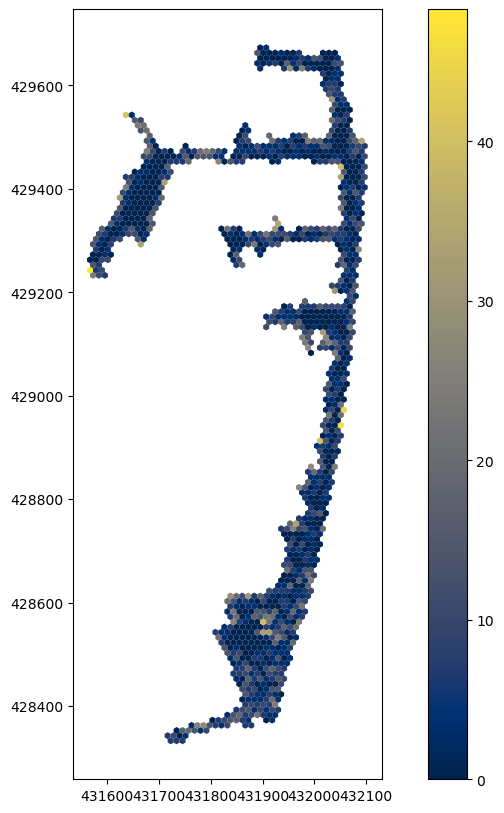

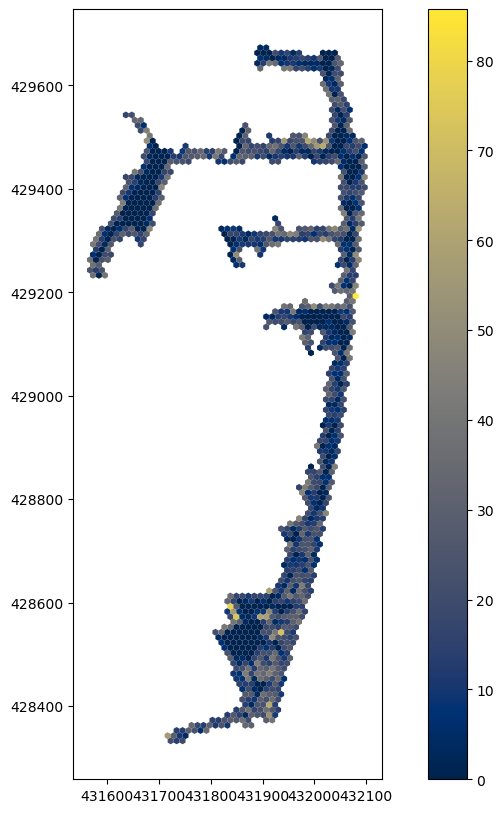

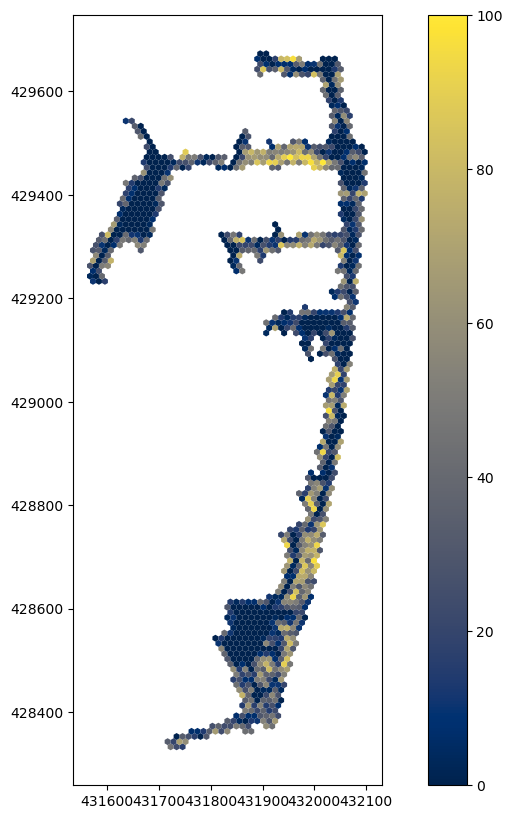

In [104]:
foliage_clipped.plot(column='low_level_<0.5', cmap='cividis', legend=True, figsize=(12, 10),)

foliage_clipped.plot(column='mid_level_0.5-2', cmap='cividis', legend=True, figsize=(12, 10))

foliage_clipped.plot(column='tall_2+', cmap='cividis', legend=True, figsize=(12, 10))

In [105]:
import folium
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import json

# Reproject to WGS84
foliage_wgs84 = foliage_clipped.drop(columns=['centroids']).to_crs('EPSG:4326')

# Create map centered on the park
center_lat = foliage_wgs84.geometry.centroid.y.mean()
center_lon = foliage_wgs84.geometry.centroid.x.mean()

m = folium.Map(
    location=[center_lat, center_lon],
    zoom_start=14,
    tiles='CartoDB positron'
)

# Define the three columns and their properties
layers_config = [
    {'column': 'low_level_<0.5', 'name': 'Low Level (<0.5m)', 'show': True},
    {'column': 'mid_level_0.5-2', 'name': 'Mid Level (0.5-2m)', 'show': True},
    {'column': 'tall_2+', 'name': 'Tall (2m+)', 'show': True},
]

# Create color mapping function with vmin=10
cmap = cm.get_cmap('cividis')

def get_color(value, vmin=10, vmax=100):
    if value < vmin:
        return None  # No color for values below vmin
    norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
    return mcolors.to_hex(cmap(norm(value)))

# Create a layer for each column
for layer_config in layers_config:
    column = layer_config['column']
    layer_name = layer_config['name']
    
    # Convert to GeoJSON
    geojson_data = json.loads(foliage_wgs84.to_json())
    
    # Create a FeatureGroup for this layer
    fg = folium.FeatureGroup(name=layer_name, show=layer_config['show'])
    
    # Add each feature with appropriate styling
    for feature in geojson_data['features']:
        props = feature['properties']
        value = props.get(column)
        
        if value is not None and value >= 10:
            color = get_color(value)
            folium.GeoJson(
                data=feature,
                style_function=lambda x, col=color: {
                    'fillColor': col,
                    'color': 'black',
                    'weight': 0.5,
                    'fillOpacity': 0.7
                }
            ).add_to(fg)
    
    fg.add_to(m)

# Add layer control to toggle layers on/off
folium.LayerControl().add_to(m)

m.show_in_browser()

/var/folders/3s/z86xkbn12m94tfxyzcgrwf080000gn/T/ipykernel_19072/3553355135.py:11: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  center_lat = foliage_wgs84.geometry.centroid.y.mean()
/var/folders/3s/z86xkbn12m94tfxyzcgrwf080000gn/T/ipykernel_19072/3553355135.py:12: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  center_lon = foliage_wgs84.geometry.centroid.x.mean()
/var/folders/3s/z86xkbn12m94tfxyzcgrwf080000gn/T/ipykernel_19072/3553355135.py:28: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('cividis')
765:773: execut

Your map should have been opened in your browser automatically.
Press ctrl+c to return.
